# 03 - Phát hiện bất thường bằng Rolling Z-score

## Mục tiêu

1. Đọc trực tiếp bảng đặc trưng Parquet được tạo ở Task 2.
2. Tính Z-score của lợi suất theo từng mã cổ phiếu và chỉ dùng 20 phiên quá khứ.
3. Sử dụng `volume_z_20` từ Task 2 để phát hiện khối lượng tăng bất thường.
4. Phân biệt bất thường do giá, khối lượng hoặc đồng thời cả hai.
5. Loại đúng các dòng warm-up và kiểm tra chất lượng trước khi lưu kết quả.
6. Lưu kết quả ở định dạng Parquet để Task 5 có thể kết hợp với kết quả KNN.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == 'notebooks' else cwd
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import config
from src.anomaly_detection import rolling_zscore
from src.data_loader import load_table, save_table

## 1. Đọc và kiểm tra dữ liệu từ Task 2

Task 3 chỉ sử dụng `stock_features.parquet`, không đọc lại dữ liệu Excel hoặc CSV. Các cột bắt buộc được kiểm tra trước khi phát hiện bất thường.

In [2]:
required_columns = [
    'ticker', 'date', 'close', 'volume', 'return', 'abs_return',
    'intraday_range', 'relative_volume', 'volume_z_20', 'volatility_20',
]
stock_features = load_table(config.STOCK_FEATURES_FILE)
missing_columns = set(required_columns) - set(stock_features.columns)
if missing_columns:
    raise ValueError(f'Thiếu cột đầu vào từ Task 2: {sorted(missing_columns)}')

stock_features = stock_features.copy()
stock_features['date'] = pd.to_datetime(stock_features['date'], errors='raise').dt.normalize()
stock_features = stock_features.sort_values(['ticker', 'date']).reset_index(drop=True)

assert stock_features.duplicated(['ticker', 'date']).sum() == 0, 'Dữ liệu còn trùng ticker-date'
assert stock_features['ticker'].nunique() == 14, 'Số mã cổ phiếu không bằng 14'
print('File đầu vào:', config.STOCK_FEATURES_FILE)
print('Kích thước:', stock_features.shape)
print('Số mã cổ phiếu:', stock_features['ticker'].nunique())
display(stock_features.head())

File đầu vào: D:\KLTN\stock_anomaly_detection\data\processed\stock_features.parquet
Kích thước: (4690, 15)
Số mã cổ phiếu: 14


,ticker,date,open,high,low,close,volume,return,abs_return,intraday_range,volume_mean_20,volume_std_20,relative_volume,volume_z_20,volatility_20
0,ANV,2025-05-05,14.76,14.81,14.76,14.81,426000,NaN,NaN,0.003388,NaN,NaN,NaN,NaN,NaN
1,ANV,2025-05-06,13.99,15.20,13.79,15.20,3802000,0.026334,0.026334,0.100786,NaN,NaN,NaN,NaN,NaN
2,ANV,2025-05-07,15.10,15.30,14.76,15.25,686800,0.003289,0.003289,0.035762,NaN,NaN,NaN,NaN,NaN
3,ANV,2025-05-08,15.25,15.25,14.76,15.10,1323000,-0.009836,0.009836,0.032131,NaN,NaN,NaN,NaN,NaN
4,ANV,2025-05-09,15.00,15.00,14.09,14.62,1977000,-0.031788,0.031788,0.060667,NaN,NaN,NaN,NaN,NaN


## 2. Phương pháp Rolling Z-score

Z-score lợi suất tại phiên `t` được tính bằng:

`return_z_20(t) = (return(t) - mean(return trước t, 20 phiên)) / std(return trước t, 20 phiên)`

Baseline được dịch bằng `shift(1)`, vì vậy lợi suất của phiên hiện tại không tham gia tính trung bình và độ lệch chuẩn dùng để đánh giá chính phiên đó. Cách làm này tránh sử dụng dữ liệu tương lai và tránh làm giảm Z-score của điểm bất thường.

| Thành phần | Điều kiện | Ý nghĩa |
|---|---|---|
| Bất thường giá | `abs(return_z_20) > 3` | Giá tăng hoặc giảm mạnh so với 20 phiên trước |
| Bất thường khối lượng | `volume_z_20 > 3` | Khối lượng tăng mạnh so với 20 phiên trước |
| Bất thường tổng hợp | Giá hoặc khối lượng bất thường | Phiên cần được phân tích tiếp |

Khối lượng thấp bất thường không được gắn cờ vì mục tiêu của đề tài là tìm các phiên giao dịch tăng đột biến.

In [3]:
window = 20
threshold = 3.0
grouped = stock_features.groupby('ticker', sort=False)

stock_features['return_mean_20'] = grouped['return'].transform(
    lambda values: values.shift(1).rolling(window, min_periods=window).mean()
)
stock_features['return_z_20'] = grouped['return'].transform(
    lambda values: rolling_zscore(values, window=window)
)

stock_features['return_anomaly'] = stock_features['return_z_20'].abs().gt(threshold)
stock_features['volume_anomaly'] = stock_features['volume_z_20'].gt(threshold)
stock_features['zscore_anomaly'] = stock_features['return_anomaly'] | stock_features['volume_anomaly']
stock_features['anomaly_score'] = np.maximum(
    stock_features['return_z_20'].abs(),
    stock_features['volume_z_20'].clip(lower=0),
)
stock_features['anomaly_type'] = np.select(
    [
        stock_features['return_anomaly'] & stock_features['volume_anomaly'],
        stock_features['return_anomaly'],
        stock_features['volume_anomaly'],
    ],
    ['price_and_volume', 'price', 'volume'],
    default='normal',
)

## 3. Xử lý warm-up và kiểm tra chất lượng

Mỗi mã cần 21 dòng warm-up để tính Z-score lợi suất đầu tiên: một dòng để hình thành lợi suất đầu tiên và 20 lợi suất quá khứ để tạo baseline. Với 14 mã, tổng số dòng warm-up dự kiến là `21 × 14 = 294`.

Các dòng này được loại thay vì điền bằng 0, vì giá trị 0 có thể khiến mô hình hiểu nhầm rằng phiên đó hoàn toàn bình thường.

In [4]:
model_columns = ['return_z_20', 'volume_z_20', 'anomaly_score']
zscore_results = stock_features.dropna(subset=model_columns).copy().reset_index(drop=True)
expected_rows = int((stock_features.groupby('ticker').size() - (window + 1)).clip(lower=0).sum())

assert len(zscore_results) == expected_rows, 'Số dòng sau warm-up không đúng dự kiến'
assert zscore_results['ticker'].nunique() == stock_features['ticker'].nunique(), 'Bị mất ticker sau warm-up'
assert zscore_results.duplicated(['ticker', 'date']).sum() == 0, 'Kết quả còn trùng ticker-date'
assert np.isfinite(zscore_results[model_columns]).all().all(), 'Kết quả có NaN hoặc vô cực'
assert zscore_results[['return_anomaly', 'volume_anomaly', 'zscore_anomaly']].dtypes.eq(bool).all(), 'Cột cờ không phải boolean'
assert (zscore_results['zscore_anomaly'] == (zscore_results['return_anomaly'] | zscore_results['volume_anomaly'])).all(), 'Cờ tổng hợp không nhất quán'

quality_report = pd.Series({
    'Số dòng đầu vào': len(stock_features),
    'Số dòng warm-up đã loại': len(stock_features) - len(zscore_results),
    'Số dòng hợp lệ': len(zscore_results),
    'Bất thường giá': int(zscore_results['return_anomaly'].sum()),
    'Bất thường khối lượng': int(zscore_results['volume_anomaly'].sum()),
    'Bất thường tổng hợp': int(zscore_results['zscore_anomaly'].sum()),
    'Tỷ lệ bất thường': float(zscore_results['zscore_anomaly'].mean()),
})
print('BÁO CÁO PHÁT HIỆN BẤT THƯỜNG Z-SCORE')
display(quality_report.rename('Giá trị').to_frame())
print('Tất cả kiểm tra chất lượng Rolling Z-score đều đạt.')

BÁO CÁO PHÁT HIỆN BẤT THƯỜNG Z-SCORE


,Giá trị
Số dòng đầu vào,4690.000000
Số dòng warm-up đã loại,294.000000
Số dòng hợp lệ,4396.000000
Bất thường giá,126.000000
Bất thường khối lượng,157.000000
Bất thường tổng hợp,232.000000
Tỷ lệ bất thường,0.052775


Tất cả kiểm tra chất lượng Rolling Z-score đều đạt.


In [5]:
anomalies_by_ticker = (
    zscore_results.groupby('ticker')
    .agg(
        sessions=('date', 'size'),
        return_anomalies=('return_anomaly', 'sum'),
        volume_anomalies=('volume_anomaly', 'sum'),
        combined_anomalies=('zscore_anomaly', 'sum'),
        anomaly_rate=('zscore_anomaly', 'mean'),
    )
)
display(anomalies_by_ticker)

,sessions,return_anomalies,volume_anomalies,combined_anomalies,anomaly_rate
ticker,,,,,
ANV,314,5,10,13,0.041401
DBC,314,8,10,15,0.047771
DGW,314,5,14,17,0.054140
DHG,314,12,9,18,0.057325
FRT,314,10,11,17,0.054140
IMP,314,10,12,20,0.063694
MSN,314,9,14,18,0.057325
MWG,314,6,8,11,0.035032
PNJ,314,11,11,17,0.054140


## 4. Kiểm tra các phiên bất thường mạnh nhất

`anomaly_score` là giá trị lớn hơn giữa độ lớn Z-score lợi suất và Z-score khối lượng dương. Điểm này dùng để xếp hạng mức độ đáng chú ý, không phải xác suất bất thường.

In [6]:
result_columns = [
    'ticker', 'date', 'close', 'volume', 'return', 'return_z_20',
    'volume_z_20', 'return_anomaly', 'volume_anomaly',
    'zscore_anomaly', 'anomaly_score', 'anomaly_type',
]
top_anomalies = (
    zscore_results.loc[zscore_results['zscore_anomaly'], result_columns]
    .sort_values('anomaly_score', ascending=False)
    .head(30)
)
display(top_anomalies)

,ticker,date,close,volume,return,return_z_20,volume_z_20,return_anomaly,volume_anomaly,zscore_anomaly,anomaly_score,anomaly_type
2786,PNJ,2026-07-08,52.00,25605600,0.023622,1.112948,46.404083,False,True,True,46.404083,volume
1041,DHG,2025-10-22,99.94,110900,0.039526,20.054805,20.361777,True,True,True,20.361777,price_and_volume
3363,SAB,2026-04-23,45.10,3372800,0.069988,5.751531,17.620860,True,True,True,17.620860,price_and_volume
1864,IMP,2026-08-05,36.80,89000,0.019391,1.158118,14.826962,False,True,True,14.826962,volume
1761,IMP,2026-03-10,55.58,187900,0.050265,14.717110,2.784844,True,False,True,14.717110,price
4239,VNM,2026-01-14,65.55,24838300,0.069506,3.944848,13.548511,True,True,True,13.548511,price_and_volume
3267,SAB,2025-12-01,43.97,4104800,0.055956,8.538619,13.119584,True,True,True,13.119584,price_and_volume
2671,PNJ,2026-01-16,71.80,4710600,0.061031,4.653078,12.790641,True,True,True,12.790641,price_and_volume
2607,PNJ,2025-10-16,60.81,2980200,0.069657,7.746977,12.705324,True,True,True,12.705324,price_and_volume
622,DBC,2026-08-25,17.70,8747300,0.066265,4.978466,12.201210,True,True,True,12.201210,price_and_volume


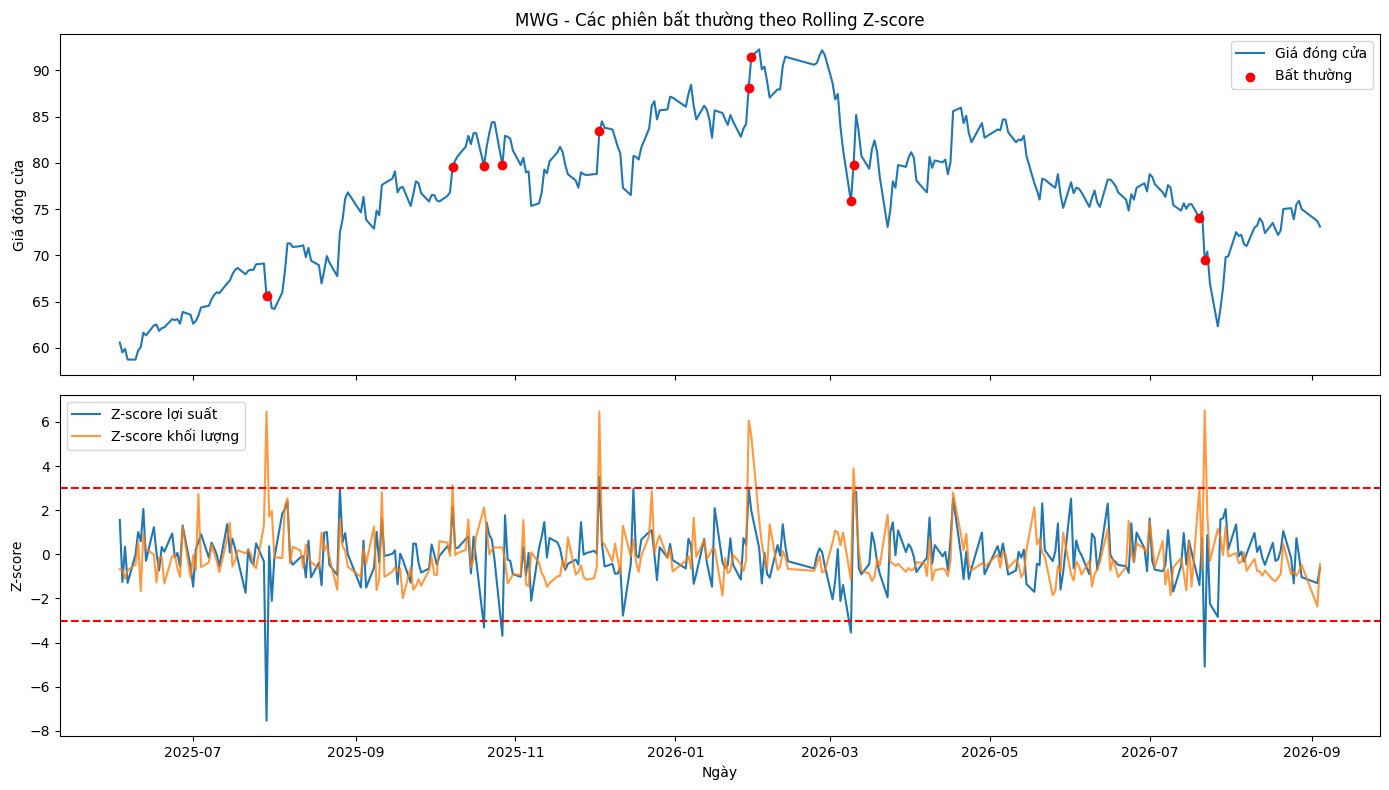

In [7]:
mwg = zscore_results.loc[zscore_results['ticker'].eq('MWG')].copy()
mwg_anomalies = mwg.loc[mwg['zscore_anomaly']]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(mwg['date'], mwg['close'], label='Giá đóng cửa')
axes[0].scatter(mwg_anomalies['date'], mwg_anomalies['close'], color='red', label='Bất thường', zorder=3)
axes[0].set_ylabel('Giá đóng cửa')
axes[0].legend()
axes[0].set_title('MWG - Các phiên bất thường theo Rolling Z-score')
axes[1].plot(mwg['date'], mwg['return_z_20'], label='Z-score lợi suất')
axes[1].plot(mwg['date'], mwg['volume_z_20'], label='Z-score khối lượng', alpha=0.8)
axes[1].axhline(threshold, color='red', linestyle='--')
axes[1].axhline(-threshold, color='red', linestyle='--')
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('Z-score')
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Giải thích các cột kết quả

- `return_mean_20`: lợi suất trung bình của 20 phiên trước.
- `return_z_20`: mức lệch chuẩn hóa của lợi suất hiện tại so với lịch sử.
- `return_anomaly`: cờ giá tăng hoặc giảm bất thường.
- `volume_anomaly`: cờ khối lượng tăng bất thường.
- `zscore_anomaly`: cờ tổng hợp, bằng `True` nếu giá hoặc khối lượng bất thường.
- `anomaly_score`: điểm dùng để xếp hạng mức độ bất thường.
- `anomaly_type`: `price`, `volume`, `price_and_volume` hoặc `normal`.

## 6. Lưu kết quả

In [8]:
save_table(zscore_results, config.ZSCORE_ANOMALIES_FILE)
check = load_table(config.ZSCORE_ANOMALIES_FILE)
pd.testing.assert_frame_equal(check, zscore_results)

print('Đã lưu kết quả vào:', config.ZSCORE_ANOMALIES_FILE)
print('Kích thước đầu ra:', check.shape)

Đã lưu kết quả vào: D:\KLTN\stock_anomaly_detection\data\processed\zscore_anomalies.parquet
Kích thước đầu ra: (4396, 22)


## 7. Kết luận Task 3

Sau khi notebook chạy thành công:

- Dữ liệu warm-up đã được loại đúng và không được điền giả bằng 0.
- Mỗi phiên chỉ được so sánh với lịch sử của chính ticker đó.
- Baseline không chứa phiên hiện tại hoặc dữ liệu tương lai.
- Kết quả vẫn giữ khóa `ticker-date` để liên kết với KNN và tin tức.
- File `zscore_anomalies.parquet` sẵn sàng cho bước kết hợp mô hình.

**Bước tiếp theo:** chạy Task 4 để phát hiện bất thường bằng KNN trên cùng tập đặc trưng và cùng phạm vi phiên hợp lệ.